# Variational Inference: Spam Detection

In this assignment, we will load the UCI SMS Spam Collection dataset.
However, instead of using it directly, we will use fixed-size vector embeddings of the message.
Those embeddings have already been produced and are provided here to you.


## Setting the Scene

The goal of this assignment to go beyond a traditional classifier and apply variational methods.
This means that we will train a model using some parameters over the distribution of which we have a prior belief.
Our prior belief here is actually that each and every parameter independently follows a standard normal distribution.


During optimization, we will draw sets of parameters from our variational distribution $q_{\phi}$.
Drawing these parameters needs to be done using the reparameterization trick, so that we can add noise, i.e., $w_i=\mu_i+\sigma_i\cdot\epsilon$.
The assignment also poses one or the other question (clearly marked), you need to provide your answer directly after.


The assignment has some blank spots for you to fill out (but you can customize your implementation to your liking).
Training should be done using stochastic gradient descend, either using manual gradient updates or using an optimizer.

You should use autodiff-capabilities to compute gradients.
It is recommended to use, for example, JAX or PyTorch.
We recommend the latter, using it in a functional way (i.e., using `torch.func.jacrev`).
The blanks left in this assignment and their type hints assume PyTorch.
There are some cells with quick tests/sanity-checks, that you are free to remove, especially if they do not go along with how you chose to implement your solution.


At the end of the assignment, after training, you need to pick one advanced method of evaluation.
We are not interested in traditional metrics here (e.g., accuracy, Kappa, F1, etc.; although you are welcome to show those).
Rather, we want to exploit the variational nature of the model here and show something more interesting.

# Load the Data

You're variational model shall use no more than 15 components (aim for ~5 or fewer).
You'll have to apply a dimensionality reduction.

Sentence Embeddings were created in two ways:

1. (Recommended) Using [ALBERT XLarge v2](https://huggingface.co/albert/albert-xlarge-v2) (`albert-xlarge-v2`). Dim $=2,048$.
2. Using [English word vectors](https://fasttext.cc/docs/en/english-vectors.html) from `wiki-news-300d-1M` using `fasttext`. Dim $=300$.

In either case, the embeddings were averaged along the sequence dimension to produce fixed-size vectors.
In the provided dataset, the messages are retained.
This is useful should you choose a qualitative evaluation.

The labels have already been converted to floats: 0.0=ham, 1.0=spam.
The default example below shows a spam message.

In [1]:
# Modify only the file you wish to load.
# Each data file contains 3 keys: X, y, msg
import numpy as np

data = np.load(file='data/2048d_sms_spam_albert-xlarge-v2.npz')
# data = np.load(file='300d_sms_spam_fasttext_pca.npz')

X: np.ndarray; Y: np.ndarray
X, Y, msg = data.get('X'), data.get('y'), data.get('msg')
X.shape, Y.shape, len(msg), msg[2], Y[2]

((5572, 2048),
 (5572,),
 5572,
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
 1)

# Define the Model

Our model is to be a polynomial with degree corresponding to the number of components chosen for the PCA.

$$
\begin{align}
    z=w_0+w_1\cdot x_1+w_2x_2^2+\dots+w_nx_n^n.
\end{align}
$$

We will perform a **binary** classification problem, using the binary cross-entropy (CE).
CE has a range of $[0,\infty)$.
The better the predictions of our model, the lower the CE.


Note that binary CE requires our predictions to be in the range $[0,1]$.
Therefore, we will have to pass its raw outputs ("logits") through the Sigmoid function.
This makes our model a **logistic** classifier.
The Sigmoid function is defined as $s(x)=\frac{1}{1+e^{-z}}$.

$$
\begin{align}
    p_i&=s(z_i),\;\text{convert our raw predictions to probabilities, then:}
    \\[1ex]
    \hat{y}_i&\sim\text{Bernoulli}(p_i).
\end{align}
$$


Since our predicted $\hat{y}$ will follow a Bernoulli distribution, we can directy use its likelihood function.
Note that maximizing the Bernoulli likelihood is equivalent of minimizing the binary CE!
The Bernoulli distribution is parameterized by a single parameter, **$p$**.


However, in our context, $p$ is unknown.
In order not to confuse the Bernoulli distribution's parameter $p$ with anything, in the following, we have substituted it with $s(z_i)$.
We will optimize for it, so that the output of our logisitic classifier becomes $p$.
The likelihood (for the prediction $\hat{y}_i$ of a single observation and its label $y_i$) then becomes:

$$
\begin{align}
    p(\mathbf{y}|\mathbf{X},\mathbf{w})&=\prod_i\,s(z_i)^{y_i}\cdot(1-s(z_i))^{1-y_i},
    \\
    \log{(p(\mathbf{y}|\mathbf{X},\mathbf{w}))}&=\sum_i\,\left[\log{(s(z_i)^{y_i})}+\log{((1-s(z_i))^{1-y_i})}\right],
    \\
    &=\sum_i\,\left[y_i\cdot\log{(s(z_i))} + (1-y_i)\cdot\log{(1-s(z_i))}\right].
\end{align}
$$

* Our **prior** belief is that each parameter follows a standard normal distribution, i.e., $w_j\sim\mathcal{N}(0,1)$.
* For our variational distribution, use a mean-field approximation of standard (independent) normals, too.


**Question**: Conceptually, how does the log-likelihood $p(y|x,w)$ compute its result given a single $n$-dimensional observation under the assumption of independent dimensions?

**Answer**: In case of independent dimensions, the (log-)likelihood across all dimensions is multiplied (summed).

# Implement the Model

Here, you are encouraged to use a library/framework like PyTorch or JAX and esp. functionality for automatic differentiation to compute gradients.
You may also import functions like `sigmoid` or `vmap` for vectorized operations.

It is recommended to implement vectorized versions of your required functions (i.e., batch-processing).

It is preferable to use type-hints for your functions.
Furthermore, you can write better code by inserting assertions (e.g., for dimensionality or other sanity-checks).
Please use Python-style comments like in the following:

```python
def func(w0: float, x: float) -> float:
    """
    Function to compute a multiple of x.
    """
    ...
```

In [2]:
import torch
from torch import Tensor


def model(w: Tensor, x: Tensor) -> Tensor:
    """
    Takes the coefficients w, the observations, computes the polynomial and
    returns probabilities.
    """
    linear = torch.sum(w[1:] * x, dim=1)
    return torch.sigmoid(w[0] + linear)

In [3]:
# Sanity-check, we should get 4 outputs if the model is correctly vectorized!
temp = model(w=torch.rand(size=(6,)), x=torch.rand(size=(4,5)))
temp

tensor([0.8947, 0.8778, 0.8414, 0.8548])

## The Likelihood function

In [4]:
def log_lik(y_true: Tensor, y_hat: Tensor) -> Tensor:
    """
    For one or more observations, where y_true is the true label (0 or 1)
    and y_hat contains predicted probabilities [0,1], computes the (log)
    likelihood.
    """
    # Ensure inputs are 1D for element-wise operations
    y_true = y_true.flatten()
    y_hat = y_hat.flatten()

    # Add small epsilon to avoid log(0)
    eps = 1e-8
    y_hat = torch.clamp(y_hat, min=eps, max=1)

    # Compute the log likelihood
    ll = torch.sum(y_true * torch.log(y_hat) + (1 - y_true) * torch.log(1 - y_hat))

    return ll

In [5]:
# Sanity-check, should be a single element here:
log_lik(y_true=torch.tensor(data=[1,0,1,0], dtype=torch.float), y_hat=temp)

tensor(-4.3155)

# The Evidence Lower BOund (ELBO)

Optimizing the ELBO (maximization) is the same as minimizing the KL divergence.
Here, the students shall implement a **Monte Carlo** approximation.

According to the slides, this is how it's done:

1. Sample from approximate posterior distribution $q_{\phi}(\theta)$.
    * Direct sampling methods should be used (we have a well-defined mean-field approximation here).
    * Apply reparameterization trick to train the model. Note: Do **not** use amortized variational inference here.
2. Estimate the ELBO using stochastic gradient-based optimization.

---------

Remember that the Bayesian framework tells us something about the *model*.
The variational approach allows us to **empirically** estimate the overall goodness of fit of our model.

In order to do that sufficiently well, we need more than just point estimates.
Recall that we do **not** attempt to find some best point estimates for our data, but rather a distribution over them.
In order for that to work well, we need to test many different parameter constellations and average over those results.
In other words, we need to draw many different sets of possible variational distribution parameters and check how well these allow our model, on average, to predict the constant observations.


-------

Recall the definition of the ELBO:

$$
\begin{align}
    \text{ELBO}&=\mathbb{E}_{q_{\phi}(\mathbf{w})}\left[\log{(p(\mathbf{y}|\mathbf{X},\mathbf{w}))}\right]-D_{\text{KL}}\left(q_{\phi}(\mathbf{w})\|p(\mathbf{w})\right).
\end{align}
$$

-------

For simplicity here, assume there will be the following "loops":

1. Outermost loop is governed by the epoch ($E$).
2. The next loop is over the stochastic mini-batches of observations (batches of size $N$).
    * For each batch, you draw $w^{(s)}\in 1\dots S$ **new** different sets of parameter configurations from your variational distribution.
    * Here, you'll be using the reparameterization trick.
3. Loop over $S$:
    * (a) For each configuration $s_i$, you will have to multiply (sum) the (log) likelihood of each observation under the current likelihood function (as parameterized by $w^{(s)}$).
    * (b) Next, calculate the KL-divergence between our approximate posterior (the mean-field approximation of independent Gaussians) and our prior (which is a diagonal standard normal distribution). **Attention**:
        * You use either, the **analytical** or the **Monte Carlo** approximation of the KL-divergence. However, the analytical one is essentially *outside the expectation* (because it does not average over $w^{(s)}$), whereas the MC-approximation should perhaps be an addend/subtrahend to (a).
        * In effect, the analytical KL-divergence is calculated only **once** per batch, using the **current** variational parameters (i.e., as they were after the last optimizer's step or after initialization for first step).
    * Calculate (a) - (b), according to previous remark.
4. Average the results from step 3 (considering the remark about analytical/MC version of the KL-divergence). It needs to be an average because the ELBO is an expectation (a weighted mean) over all possible realizations of $s_i\in S$. For each individual batch, you have now an average idea of:
    * The *expected* data likelihood.
    * How strongly your prior and approximate posterior diverge from one another.
5. Do not accumulate results across batches at this point.
    * It is better to compute a gradient for each batch and apply parameter updates. Frequent, incremental updates work better in practice.


**Notes**:
* As $S$ approaches $\infty$, the MC-approximation of the KL-divergence will be equal to the analytical solution.
* For the MC-approximation, a good $S$ is perhaps $50-500$.

# Putting it all together

Let's implement the "loops" from above.
We will create stochastic mini-batches of our data to compute gradients on.
For now, we will not implement a loop for epochs.

The ELBO for a list of parameters sets $S$ and a mini-batch of length $N$ is defined as follows:

$$
\begin{align}
    \text{ELBO}(\phi)&\approx\left(\frac{1}{S}\sum_{s=1}^{S}\,\underbrace{\left[\sum_{i=1}^{N}\,\log{(p(y_i|x_i,w^{(s)}))}\right]}_{\text{log-sum of i.i.d. observations}}\right)-\underbrace{D_{\text{KL}}(q_{\mu,\sigma}(w)\|p(w))}_{\text{using the current $\mu,\sigma$}}.
    \\[4em]
    \text{Also note that}&\text{ we can use Monte Carlo to approximate the KL-divergence:}\nonumber
    \\[1em]
    D_{\text{KL}}(q_{\mu,\sigma}(w)\|p(w))&=\mathbb{E}_{w\sim q_{\mu,\sigma}(w)}\left[\log{\left(\frac{q_{\mu,\sigma}(w)}{p(w)}\right)}\right],
    \\[1em]
    &=\frac{1}{S}\sum_{s=1}^{S}\,\left[\log{\left(q_{\mu,\sigma}\left(w^{(s)}\right)\right)}-\log{\left(p\left(w^{(s)}\right)\right)}\right].
    \\[2em]
    \text{Also note that}&\text{ the KL-divergence between two normals has an analytical solution:}\nonumber
    \\[1em]
    D_{\text{KL}}(q_{\mu,\sigma}(w)\|\mathcal{N}(0,I))&=\frac{1}{2}\sum_{j=0}\,\left(\mu_j^2+\sigma_j^2-1-\log{\left(\sigma_j^2\right)}\right).
    \\[2em]
    \text{Also note that}&\text{ the ELBO including the MC-approximation of the KL-divergence is:}\nonumber
    \\[1em]
    \text{ELBO}(\phi)&\approx\frac{1}{S}\sum_{s=1}^{S}\,\underbrace{\left[\sum_{i=1}^{N}\,\log{(p(y_i|x_i,w^{(s)}))}\right]}_{\text{log-sum of i.i.d. observations}}-\underbrace{\left[\log{\left(q_{\mu,\sigma}\left(w^{(s)}\right)\right)}-\log{\left(p\left(w^{(s)}\right)\right)}\right]}_{\text{MC-approx. of KL-divergence}}.
\end{align}
$$

# Implementation

Here, implement everything you need.

## Data Preparation and Dimensionality Reduction

Start by reducing the dimensionality of your data.
Choose a combination of dataset and polynomial degree that is not too low and not too high.
Aim for at least 30% explained variance and at most 15 components.

Report the (sum of the) explained variance before you proceed.


Remember the basics: splitting, randomness, scaling, etc.

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


print(f"Original shape: {X.shape}")
print(f"Original Y shape: {Y.shape}")

POLY_DEGREE = 3

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=POLY_DEGREE)
X_pca = pca.fit_transform(X_scaled)

print(f"\nReduced shape: {X_pca.shape}")
print(f"Variance explained by {POLY_DEGREE} components: {pca.explained_variance_ratio_.sum():.2%}")

Original shape: (5572, 2048)
Original Y shape: (5572,)

Reduced shape: (5572, 3)
Variance explained by 3 components: 34.21%


## Model

Below you'll find some prototypes (fill in the blanks).
Again, this is just a suggestion, you can come up with your own implementation.

In [7]:
import torch.nn.functional as F


def ELBO_expected_data_likelihood(y_true: Tensor, x: Tensor, W: Tensor) -> Tensor:
    """A function to calculate the first term of the ELBO."""
    N = y_true.shape[0]  # Mini-batch size
    S = W.shape[0]       # Number of Monte Carlo samples

    total_log_lik = 0.0

    for s in range(S):
        w_sample = W[s]

        y_pred = model(w=w_sample, x=x)

        # I have to use the built in version because I get issues with numerical instability
        log_lik_s = -F.binary_cross_entropy(y_pred, y_true, reduction='sum')
        total_log_lik += log_lik_s
        if total_log_lik == -torch.inf:
            print("STOP")
            quit()

    expected_log_lik = total_log_lik / S
    return expected_log_lik


def ELBO_KL_divergence_analytical(mu: Tensor, sigma: Tensor) -> Tensor:
    """The analytical version of the KL divergence."""
    kl = 0.5 * torch.sum(mu**2 + sigma**2 - 1 - torch.log(sigma**2 + 1e-8))
    return kl

In [8]:
from typing import Literal

NUM_VARIATIONAL_SETS = 50
KL_DIV_TYPE = Literal['analytical']


def ELBO(use_mu: Tensor, use_sigma: Tensor, y_true: Tensor, obs: Tensor,
         variational_params_noise: Tensor, kl: KL_DIV_TYPE = 'analytical',
         return_exp_data_lik: bool = False, return_kl_div: bool = False) -> Tensor | tuple[Tensor, ...]:
    """
    Convenience function that uses the current variational parameters,
    applies the reparameterization trick, and computes the complete
    ELBO. The result of this function shall be maximized.

    Args:
        use_mu: Mean parameters of shape (D,) or (D+1,)
        use_sigma: Standard deviation parameters of shape (D,) or (D+1,)
        y_true: True labels of shape (N,)
        obs: Observations/features of shape (N, D)
        variational_params_noise: Random noise for reparameterization of shape (S, D)
        kl: Type of KL divergence to use ('analytical' or 'montecarlo')
        return_exp_data_lik: If True, return the expected data likelihood term
        return_kl_div: If True, return the KL divergence term

    Returns:
        ELBO value, and optionally the data likelihood and KL divergence terms
    """
    # Number of Monte Carlo samples
    S = variational_params_noise.shape[0]

    # Reparameterization trick: w = mu + sigma * epsilon
    # where epsilon ~ N(0, I)
    W = use_mu + use_sigma * variational_params_noise  # Shape: (S, D)

    # Compute expected data likelihood term
    exp_data_lik = ELBO_expected_data_likelihood(y_true, obs, W)

    kl_div = ELBO_KL_divergence_analytical(use_mu, use_sigma)

    # Compute ELBO
    elbo_value = exp_data_lik - kl_div

    # Return based on flags
    if return_exp_data_lik and return_kl_div:
        return elbo_value, exp_data_lik, kl_div
    elif return_exp_data_lik:
        return elbo_value, exp_data_lik
    elif return_kl_div:
        return elbo_value, kl_div
    else:
        return elbo_value


# Define the gradient of the ELBO function using torch.autograd
def create_ELBO_gradient_function(kl_type: KL_DIV_TYPE = 'analytical'):
    """
    Creates a function that computes the gradient of ELBO with respect to 
    variational parameters (mu and sigma).

    Args:
        kl_type: Type of KL divergence to use

    Returns:
        A function that computes ELBO gradients
    """
    def ELBO_grad(mu: Tensor, sigma: Tensor, y_true: Tensor, obs: Tensor, 
                  variational_params_noise: Tensor) -> tuple[Tensor, Tensor]:
        """
        Compute gradients of ELBO with respect to mu and sigma.

        Args:
            mu: Mean parameters requiring gradients
            sigma: Standard deviation parameters requiring gradients
            y_true: True labels
            obs: Observations
            variational_params_noise: Random noise for reparameterization

        Returns:
            Tuple of (grad_mu, grad_sigma)
        """
        # Ensure parameters require gradients
        mu = mu.requires_grad_(True)
        sigma = sigma.requires_grad_(True)

        # Compute ELBO
        elbo_value = ELBO(mu, sigma, y_true, obs, variational_params_noise, kl=kl_type)

        # Compute gradients
        elbo_value.backward()

        # Return gradients
        mu_grad, sigma_grad = mu.grad.clone(), sigma.grad.clone()

        # Turn of the gradient computation
        mu = mu.requires_grad_(False)
        sigma = sigma.requires_grad_(False)

        return mu_grad, sigma_grad

    return ELBO_grad

# Training

Train your model until convergence.
Choose a number of iterations, batch-size, and learning rate that make sense in your scenario.
Do not perform a grid search or other hyperparameter optimization.
Instead, manually find some good working parameters and make your final solution just use these.


* **Plot** the training curve (i.e., plot the history for each component of the ELBO).
* **Print** the final parameters for your variational distribution after optimization.
* **Evaluate** the ELBO on the holdout dataset. Is it close? You could also do this during training.


Training Configuration:
  Input dimension: 4
  Batch size (N): 64
  Monte Carlo samples (S): 50
  Epochs: 50
  Learning rate: 0.001
  KL type: analytical
Epoch 1/50, Batch 50: ELBO = -57.4428, Data Lik = -49.3115, KL = 8.1314

Epoch 1/50 Summary:
  Avg ELBO: -68.4442
  Avg Expected Data Likelihood: -60.7225
  Avg KL Divergence: 7.7217
  mu: mean=-0.0066, std=0.0574
  sigma: mean=0.0804, std=0.0687

Epoch 2/50, Batch 50: ELBO = -44.9488, Data Lik = -34.5699, KL = 10.3789
Epoch 3/50, Batch 50: ELBO = -38.1883, Data Lik = -27.5040, KL = 10.6843
Epoch 4/50, Batch 50: ELBO = -38.4042, Data Lik = -27.8650, KL = 10.5391
Epoch 5/50, Batch 50: ELBO = -36.7101, Data Lik = -26.3988, KL = 10.3113
Epoch 6/50, Batch 50: ELBO = -41.6596, Data Lik = -31.4249, KL = 10.2347
Epoch 7/50, Batch 50: ELBO = -35.2907, Data Lik = -25.1997, KL = 10.0910
Epoch 8/50, Batch 50: ELBO = -35.1497, Data Lik = -25.0082, KL = 10.1414
Epoch 9/50, Batch 50: ELBO = -33.4525, Data Lik = -23.3130, KL = 10.1395
Epoch 10/50, 

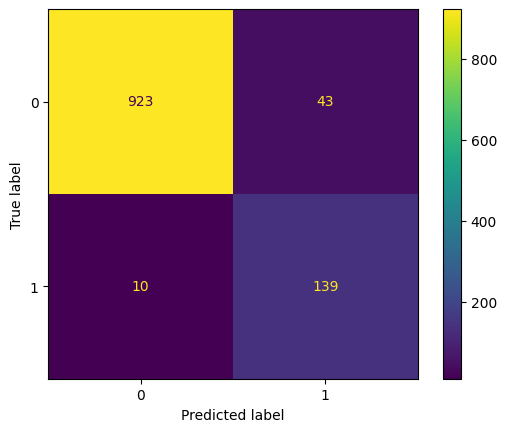

In [9]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

EPOCHS = 50
LEARNING_RATE = 0.0001
USE_KL_TYPE: KL_DIV_TYPE = 'analytical'


def initialize_variational_params(input_dim: int, init_scale: float = 0.01):
    """
    Initialize variational parameters mu and sigma.

    Args:
        input_dim: Dimension of input features (including bias if needed)
        init_scale: Scale for random initialization

    Returns:
        mu, sigma tensors that require gradients
    """
    mu = torch.randn(input_dim) * init_scale
    sigma = torch.abs(torch.randn(input_dim) * init_scale) + 0.1  # Ensure positive
    mu.requires_grad_(True)
    sigma.requires_grad_(True)
    return mu, sigma


def create_data_loader(X: np.ndarray, Y: np.ndarray, batch_size: int, shuffle: bool = True):
    """
    Create a DataLoader for mini-batch processing.

    Args:
        X: Feature matrix of shape (n_samples, n_features)
        Y: Label vector of shape (n_samples,)
        batch_size: Size of mini-batches
        shuffle: Whether to shuffle the data

    Returns:
        DataLoader object
    """
    # Convert to torch tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    Y_tensor = torch.tensor(Y, dtype=torch.float32)

    # Create dataset and dataloader
    dataset = TensorDataset(X_tensor, Y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return dataloader


def train_variational_bayesian(X: np.ndarray, Y: np.ndarray, 
                               input_dim: int,
                               batch_size: int = 32,
                               epochs: int = EPOCHS,
                               learning_rate: float = LEARNING_RATE,
                               num_variational_sets: int = NUM_VARIATIONAL_SETS,
                               kl_type: KL_DIV_TYPE = USE_KL_TYPE,
                               verbose: bool = True) -> tuple[Tensor, Tensor, list]:
    """
    Train the variational Bayesian model using ELBO maximization.

    Args:
        X: Feature matrix of shape (n_samples, n_features)
        Y: Label vector of shape (n_samples,)
        input_dim: Dimension of input features
        batch_size: Mini-batch size N
        epochs: Number of training epochs
        learning_rate: Learning rate for optimizer
        num_variational_sets: Number of Monte Carlo samples S
        kl_type: Type of KL divergence to use
        verbose: Whether to print progress

    Returns:
        Tuple of (final_mu, final_sigma, training_history)
    """

    mu, sigma = initialize_variational_params(input_dim)

    dataloader = create_data_loader(X, Y, batch_size, shuffle=True)

    optimizer = optim.Adam([mu, sigma], lr=learning_rate)

    training_history = []

    for epoch in range(epochs):
        epoch_elbo = 0.0
        epoch_data_lik = 0.0
        epoch_kl = 0.0
        num_batches = 0

        for batch_idx, (batch_X, batch_y) in enumerate(dataloader):
            # Zero gradients from previous batch
            optimizer.zero_grad()

            N = batch_X.shape[0]

            # Generate new random noise for reparameterization trick
            # Shape: (S, D) where S = num_variational_sets, D = input_dim
            variational_params_noise = torch.randn(num_variational_sets, input_dim)

            # Compute ELBO for this batch using the current variational parameters
            # This will build the computation graph for gradients
            elbo_value, data_lik, kl_div = ELBO(mu, sigma, batch_y, batch_X, 
                            variational_params_noise, 
                            kl=kl_type,
                            return_exp_data_lik=True,
                            return_kl_div=True)

            # Negative ELBO for minimization (since we want to maximize ELBO)
            loss = -elbo_value

            # Backward pass to compute gradients
            loss.backward()

            # Update parameters
            optimizer.step()

            # Track metrics
            epoch_elbo += elbo_value.item()
            epoch_data_lik += data_lik.item()
            epoch_kl += kl_div.item()
            num_batches += 1

            # Optional: Print batch progress
            if verbose and (batch_idx + 1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx+1}: "
                      f"ELBO = {elbo_value.item():.4f}, "
                      f"Data Lik = {data_lik.item():.4f}, "
                      f"KL = {kl_div.item():.4f}")

        # Calculate average metrics for the epoch
        avg_elbo = epoch_elbo / num_batches
        avg_data_lik = epoch_data_lik / num_batches
        avg_kl = epoch_kl / num_batches

        training_history.append({
            'epoch': epoch + 1,
            'avg_elbo': avg_elbo,
            'avg_data_likelihood': avg_data_lik,
            'avg_kl_divergence': avg_kl,
            'mu_mean': mu.detach().mean().item(),
            'mu_std': mu.detach().std().item(),
            'sigma_mean': sigma.detach().mean().item(),
            'sigma_std': sigma.detach().std().item()
        })

        if verbose and epoch % 10 == 0:
            print(f"\nEpoch {epoch+1}/{epochs} Summary:")
            print(f"  Avg ELBO: {avg_elbo:.4f}")
            print(f"  Avg Expected Data Likelihood: {avg_data_lik:.4f}")
            print(f"  Avg KL Divergence: {avg_kl:.4f}")
            print(f"  mu: mean={mu.detach().mean().item():.4f}, std={mu.detach().std().item():.4f}")
            print(f"  sigma: mean={sigma.detach().mean().item():.4f}, std={sigma.detach().std().item():.4f}\n")

    return mu.detach(), sigma.detach(), training_history


def predict_with_uncertainty(X_test: np.ndarray, mu: Tensor, sigma: Tensor, 
                            num_samples: int = 100) -> tuple[np.ndarray, np.ndarray]:
    """
    Make predictions with uncertainty estimates using the variational posterior.

    Args:
        X_test: Test features of shape (n_samples, n_features)
        mu: Trained mean parameters
        sigma: Trained standard deviation parameters
        num_samples: Number of Monte Carlo samples for prediction

    Returns:
        Tuple of (mean_predictions, prediction_uncertainty)
    """
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    N = X_test_tensor.shape[0]
    D = mu.shape[0]

    # Sample weights from variational posterior
    eps = torch.randn(num_samples, D)
    W_samples = mu + sigma * eps  # Shape: (num_samples, D)

    # Make predictions for all samples
    all_predictions = []
    for w in W_samples:
        probs = model(w=w, x=X_test_tensor)
        all_predictions.append(probs)

    # Stack predictions: (num_samples, N)
    all_predictions = torch.stack(all_predictions)

    # Compute mean and uncertainty (standard deviation)
    mean_predictions = all_predictions.mean(dim=0).numpy()
    prediction_uncertainty = all_predictions.std(dim=0).numpy()

    return mean_predictions, prediction_uncertainty


from sklearn.model_selection import train_test_split

# For demonstration, use 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X_pca, Y, test_size=0.2, random_state=42)

# Determine input dimension (add 1 for bias term)
input_dim = X_train.shape[1] + 1

BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
NUM_VARIATIONAL_SETS = 50

print(f"\nTraining Configuration:")
print(f"  Input dimension: {input_dim}")
print(f"  Batch size (N): {BATCH_SIZE}")
print(f"  Monte Carlo samples (S): {NUM_VARIATIONAL_SETS}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  KL type: {USE_KL_TYPE}")

# Train the model
final_mu, final_sigma, history = train_variational_bayesian(
    X=X_train,
    Y=Y_train,
    input_dim=input_dim,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    num_variational_sets=NUM_VARIATIONAL_SETS,
    kl_type=USE_KL_TYPE,
    verbose=True
)

# Make predictions on test set
print("\nMaking predictions on test set...")
test_probs, test_uncertainty = predict_with_uncertainty(X_test, final_mu, final_sigma, num_samples=100)

# Convert to binary predictions
test_preds = (test_probs >= 0.5).astype(int)

# Calculate accuracy
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
    )

accuracy = accuracy_score(Y_test, test_preds)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, test_preds))
cm = confusion_matrix(y_true=Y_test, y_pred=test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# Advanced Model Evaluation (Pick <u>One</u>)

In this last part of the assignment, you should select **exactly one** of the following evaluation procedures.
Your task is to implement your chosen evaluation fully and clearly, produce within your notebook at least **one informative visualization**, and **provide a 100–500 word explanation** presenting:

- **Motivation:** Why you selected this particular evaluation.
- **Implementation:** How exactly your approach was implemented (with brief explanations for your visualization and choice of metrics).
- **Insights:** What interesting facts, strengths, or weaknesses were revealed from applying this evaluation.

-----

Pick one of the following:


1. **Visualization of Learned Low-dimensional Representations**
    * Visualize embeddings from your variational polynomial model using dimensionality reduction (e.g., PCA, t-SNE, UMAP).
    * Color embeddings by posterior uncertainty estimates or predictions.
    * This illustrates nicely how your model's uncertainty varies across regions of your feature space.
2. **Posterior Predictive Checks (PPC) (Visualizations of uncertainty)**
    * Posterior predictive checks evaluate your model by extending its sampled posterior parameters forward into the data space, then comparing the simulated data (from the posterior) with the real observed data.
3. **Evaluation of the ELBO on Hold-out Data and Bayesian (Probabilistic) Performance Metrics**
    * Evaluate the quality of your approximate posterior by evaluating ELBO on the hold-out set.
    * Bayesian performance metrics, for example: Log Predictive Density (LPD) and Bayesian Information Criterion (BIC)
4. **Posterior Weight Visualization**
    * Examine posterior distributions of your parameters (coefficients of your polynomial regression).
5. **Out-of-Distribution (OoD) Detection Capability incl. Likelihood-Based Evaluation (Density Estimation Quality)**
    * E.g., generate data points far away from the hold-out dataset and evaluate likelihood, uncertainty, etc.
    * Compare computed likelihood of the train- and hold-out dataset.
-----
6. **Expected Calibration Error (ECE) and Calibration Curves (Reliability Diagrams)**
    * Expected Calibration Error numerically summarizes the calibration curves, giving you a single statistic to quantify how good or poor calibration of a model is.
-----
7. **Latent Space Smoothness and Structure**
    * Generate intermediate points (linear interpolation) between latent variables from spam and non-spam messages and decode these embeddings. Good generative models produce semantically smooth interpolations.
8. **Qualitative Evaluation of a few messages**
    * Pick about ~10 messages from the holdout dataset. Among those 10, you should have some that are obviously spam, some that are ambiguous, and some that are clearly ham.
    * Evaluate the model's predictions and uncertainty about these predictions. Is there a scheme that materializes here?

0.08079000264406204


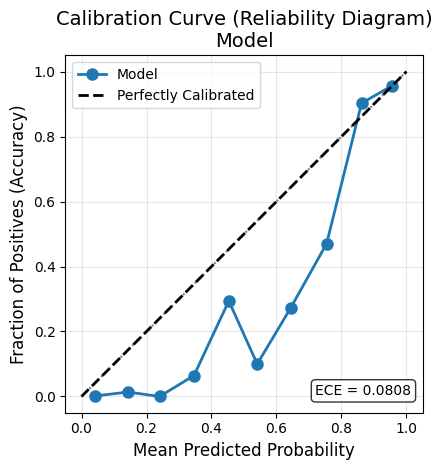

In [10]:
from sklearn.calibration import calibration_curve


def compute_ece(y_true: np.ndarray, y_probs: np.ndarray, n_bins: int = 10) -> float:
    """
    Compute Expected Calibration Error (ECE)
    
    Args:
        y_true: True labels (0 or 1)
        y_probs: Predicted probabilities (in [0,1])
        n_bins: Number of bins for grouping
    
    Returns:
        ECE score (lower is better)
    """
    # Create bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    
    ece = 0.0
    for i in range(n_bins):
        # Find samples in this bin
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        
        if i == n_bins - 1:
            # Include upper bound for last bin
            in_bin = (y_probs >= bin_lower) & (y_probs <= bin_upper)
        else:
            in_bin = (y_probs >= bin_lower) & (y_probs < bin_upper)
        
        # Skip empty bins
        if not np.any(in_bin):
            continue
        
        # Average predicted probability in this bin
        avg_pred_prob = np.mean(y_probs[in_bin])
        
        # Observed frequency (accuracy) in this bin
        observed_accuracy = np.mean(y_true[in_bin])
        
        # Weight = proportion of samples in this bin
        weight = np.sum(in_bin) / len(y_true)
        
        # Add to ECE (weighted absolute difference)
        ece += weight * np.abs(avg_pred_prob - observed_accuracy)
    
    return ece


def plot_calibration_curve(y_true: np.ndarray, y_probs: np.ndarray, 
                          model_name: str = "Model", n_bins: int = 10,
                          save_path: str = None):
    """
    Plot calibration curve (reliability diagram)
    
    Args:
        y_true: True labels (0 or 1)
        y_probs: Predicted probabilities
        model_name: Name of the model for legend
        n_bins: Number of bins
        save_path: Path to save the figure (optional)
    """
    # Get calibration curve using sklearn
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_probs, n_bins=n_bins, strategy='uniform'
    )
    
    # Create the plot
    plt.figure()
    
    # Plot calibration curve
    plt.plot(mean_predicted_value, fraction_of_positives, 
             marker='o', linewidth=2, label=model_name, markersize=8)
    
    # Plot perfect calibration line
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, 
             label='Perfectly Calibrated')
    
    # Add diagonal reference lines
    plt.plot([0, 0.5, 1], [0, 0.5, 1], 'k:', alpha=0.5)
    
    # Labels and title
    plt.xlabel('Mean Predicted Probability', fontsize=12)
    plt.ylabel('Fraction of Positives (Accuracy)', fontsize=12)
    plt.title(f'Calibration Curve (Reliability Diagram)\n{model_name}', fontsize=14)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    
    # Set axis limits
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.axis('square')
    
    # Add legend
    plt.legend(loc='upper left', fontsize=10)
    
    # Add ECE score to plot
    ece = compute_ece(y_true, y_probs, n_bins)
    plt.text(0.70, 0.05, f'ECE = {ece:.4f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Tight layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fraction_of_positives, mean_predicted_value


bins = 10

# Evaluate calibration
ece = compute_ece(Y_test, test_probs, n_bins=bins)
print(ece)

te, mp = plot_calibration_curve(Y_test, test_probs, n_bins=bins)

### Evaluation

I chose to compute the ECE (Expected Calibration Error) because it sounds cool. But it turns out it can tell you how calibrated/correctly confident the model is, with lower ece's being better.

The ECE itself is computed according to the definition:
$$\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{n} \left| \text{acc}(B_m) - \text{conf}(B_m) \right|$$
Since the model scored a ~0.08 on the ECE, it says that the model is wrong in it's prediction on average 8% of the time. It also means that the model is fairly good at predicting it's own certainty.

Looking at the Reliability Diagram we see how the model performs in each confidense bracket. By looking at the ends we see that the model knows when it is 100% or 0% certain, while looking at the middle part of the diagram we see that the model is actually severely overestimating it's own certainty.